In [94]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [95]:
# importing plotting and locus tools: 
import NEOfaster as nf
import NEOMOD3 as nm3  

In [96]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [97]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [108]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 
# add mag here
mag = 24.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [109]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i, H = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, mag, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)
print("H:", H)

neo_score: 308.0
a: 1.8147948989466378
e: 0.358504361404317
i: 26.36952675502365
H: [26.15918648]


In [91]:
def comp_sum():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    dra_vals  = np.linspace(-0.6, 0.6, N_rate)
    ddec_vals = np.linspace(-0.6, 0.6, N_rate)
    
    d_grid, ddot_grid = nf.makeddotgrids()        
    n_samples = len(d_grid) * len(ddot_grid)
    
    
    H = np.zeros((len(dra_vals), len(ddec_vals)), dtype=float)
    
    for i,dra in enumerate(dra_vals):
        for j,ddec in enumerate(ddec_vals):
            vlam, vbet = nf.radec_rates_to_ecliptic_rates1(ra0_deg, dec0_deg, dra, ddec)
            w_int = nf.weight_marginalized_over_d_and_ddot( array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        ,mag=mag)
            #break
            
            w_mean = w_int / n_samples
            H[j, i] = w_mean
            #H[j, i] = w_int
            #print(w_int, w_mean, dra, ddec)
            #break
        #break
    extent = [dra_vals[0], dra_vals[-1], ddec_vals[0], ddec_vals[-1]]
    return H, extent

H, extent= comp_sum()


In [46]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf. ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        ,mag=mag)
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



IndentationError: unexpected indent (2929138703.py, line 21)

/tmp/ipykernel_2666138/1921771529.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


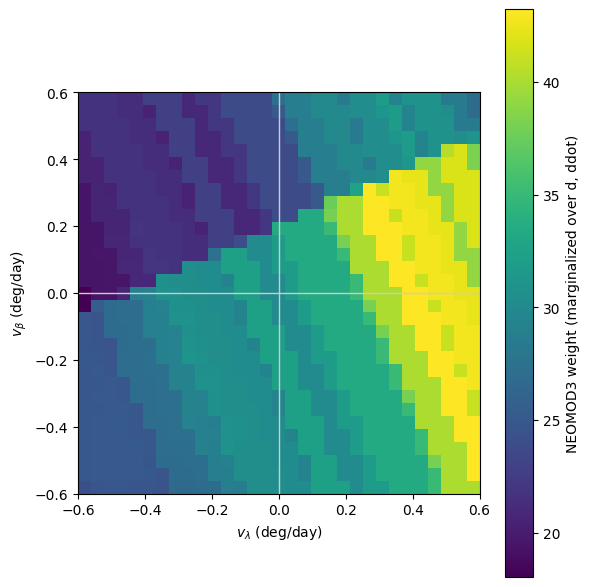

18.036891012390004 30.313013458100002 43.2337


In [92]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()


print(np.min(H), np.median(H), np.max(H))


/tmp/ipykernel_2666138/3546784570.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


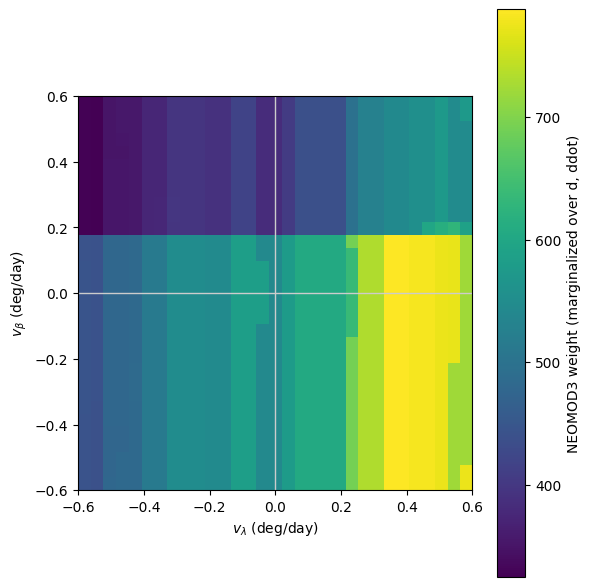

In [21]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



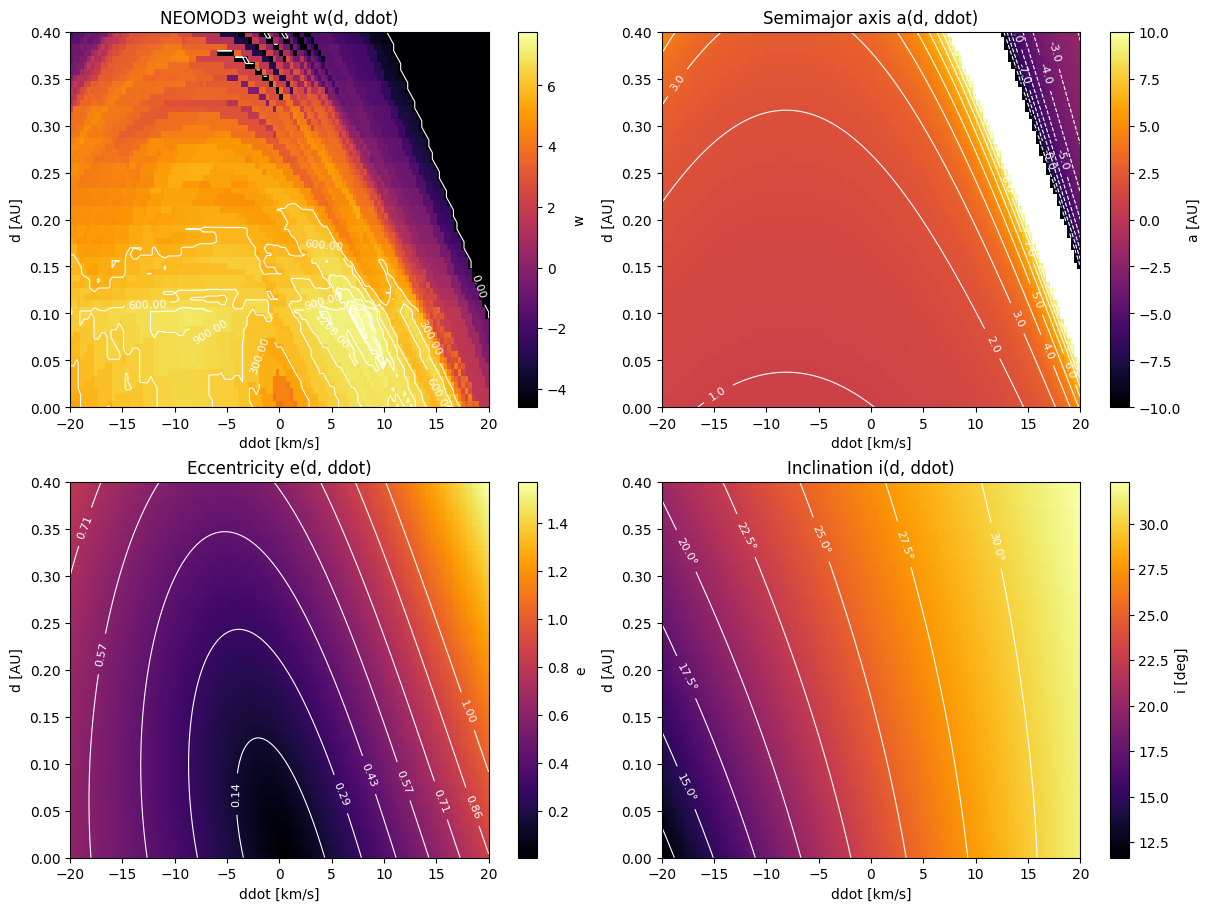

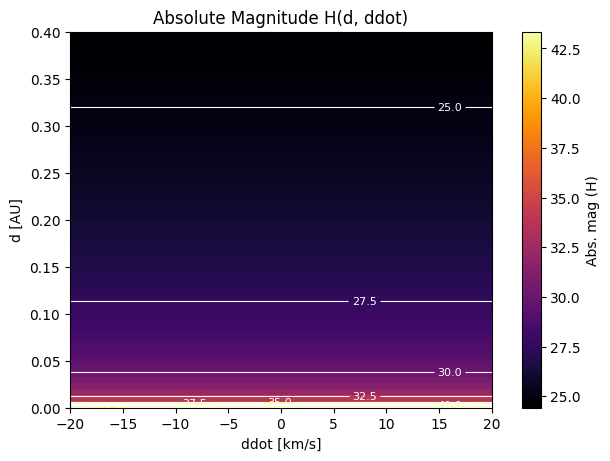

In [110]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.40, 60)   
v_vals = np.linspace(-20.0, 20.0, 120)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)   
H = np.zeros_like(W) 


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0= nf.compute_neomod3_weight(d, v, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center, i_center) 
        H_0 = np.asarray(H_0).squeeze()
        
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i,j] = np.asarray(H_0).item()


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")

fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

#absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()